In [12]:
suppressMessages({
library(BayesSpace)
library(SingleCellExperiment)
library(ggplot2)
library(Seurat)
library(cowplot)
library(RColorBrewer)
library(getopt)
library(ComplexHeatmap)
library(viridis)
library(future)
library(dplyr)
library(Matrix)
library(data.table)
library(reshape2)
})
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)
##############################################################
# set.seed(123)


In [28]:
alldata = readRDS('/data/users/heyouzhe/online/CA1_Sub_32chips.rds')

In [ ]:
# seu_subset = subset(seuobj,area_m %in% c('CA1','Sub') )
DefaultAssay(alldata) = 'RNA'
alldata@meta.data$row = alldata@meta.data$coor_y
alldata@meta.data$col = alldata@meta.data$coor_x
date()

sce <- as.SingleCellExperiment(alldata)
sce <- spatialPreprocess(sce, platform="ST", 
                     n.PCs=30, n.HVGs=3000, log.normalize=F)
date()

[1] "Tue Nov  4 09:47:58 2025"

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.7 GiB”


In [ ]:
n_clu=5
set.seed(158331)

sce <- spatialCluster(sce, q=n_clu,
                      use.dimred = 'HARMONY',
                      platform="ST", 
                      d=30,
                      init.method="mclust",
                      model="t",
                      gamma=2,
                      nrep=100, 
                      burn.in=10, 
                      save.chain=TRUE)

In [97]:
meta = colData(sce)
meta = meta[as.matrix(rownames(alldata@meta.data)),]
alldata@meta.data[,paste0("BayesSpace.clu",n_clu)] = factor(meta$spatial.cluster,levels = 1:n_clu)
Idents(alldata) = paste0("BayesSpace.clu",n_clu)
# saveRDS(meta,paste0('CA1_Sub.af_harmony.bin100_bayes',n_clu,'.rds'))

Warning message in NSBS(i, x, exact = exact, strict.upper.bound = !allow.append, :
“subscript is an array, passing it thru as.vector() first”


In [30]:
meta = readRDS('/data/users/heyouzhe/online/Region-division/01_result/CA1_Sub.af_harmony.bin100_bayes5.rds')
alldata$BayesSpace.clu5 = meta$spatial.cluster[match(row.names(alldata@meta.data),row.names(meta) )]
# alldata@meta.data[,paste0("BayesSpace.clu",n_clu)] = factor(meta$spatial.cluster,levels = 1:n_clu)


In [31]:
alldata = subset(alldata,BayesSpace.clu5 %in% c(1,2,3,4,5))

In [22]:
alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con5.1','Con5.2','Con6.1','Con6.2'),]$coor_x-500
alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('Con8.1','Con8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD4.1','AD4.2','AD5.1','AD5.2','AD6.1','AD6.2','AD8.1','AD8.2'),]$coor_x-1100
alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD7.1','AD7.2'),]$coor_x-1000
alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x = alldata@meta.data[alldata@meta.data$sample%in%c('AD2.1','AD2.2'),]$coor_x-500

In [32]:
alldata$BayesSpace.clu5 = factor(alldata$BayesSpace.clu5)
class(alldata$BayesSpace.clu5)

[1] "factor"

[1] 5

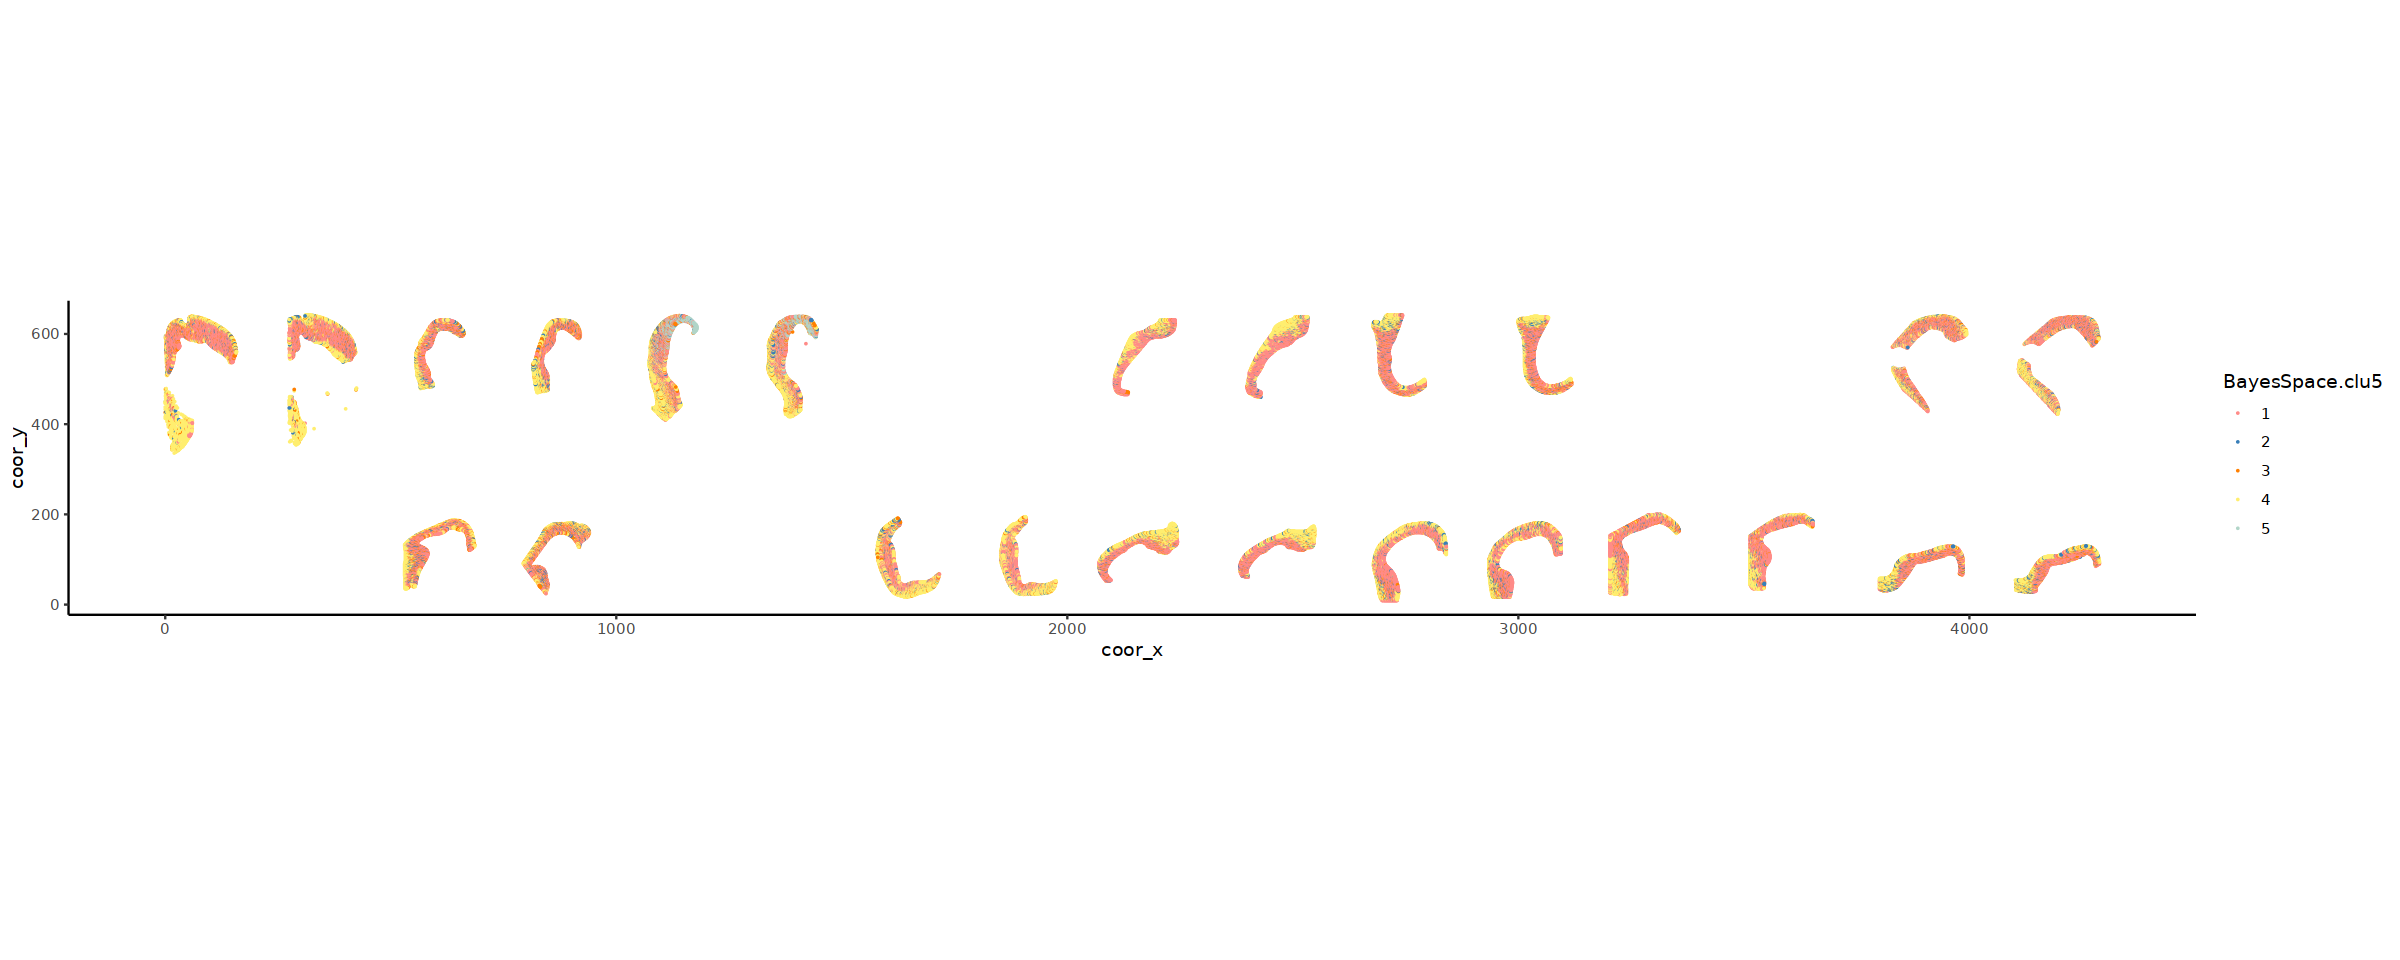

In [33]:
n_clu
ggplot(alldata@meta.data,aes(x = coor_x, y = coor_y, color = BayesSpace.clu5))+
geom_point(size = 0.001) +
scale_color_manual(values = cols) + 
theme_classic()+ coord_fixed()+ 
scale_fill_manual(values =cols)+
labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))


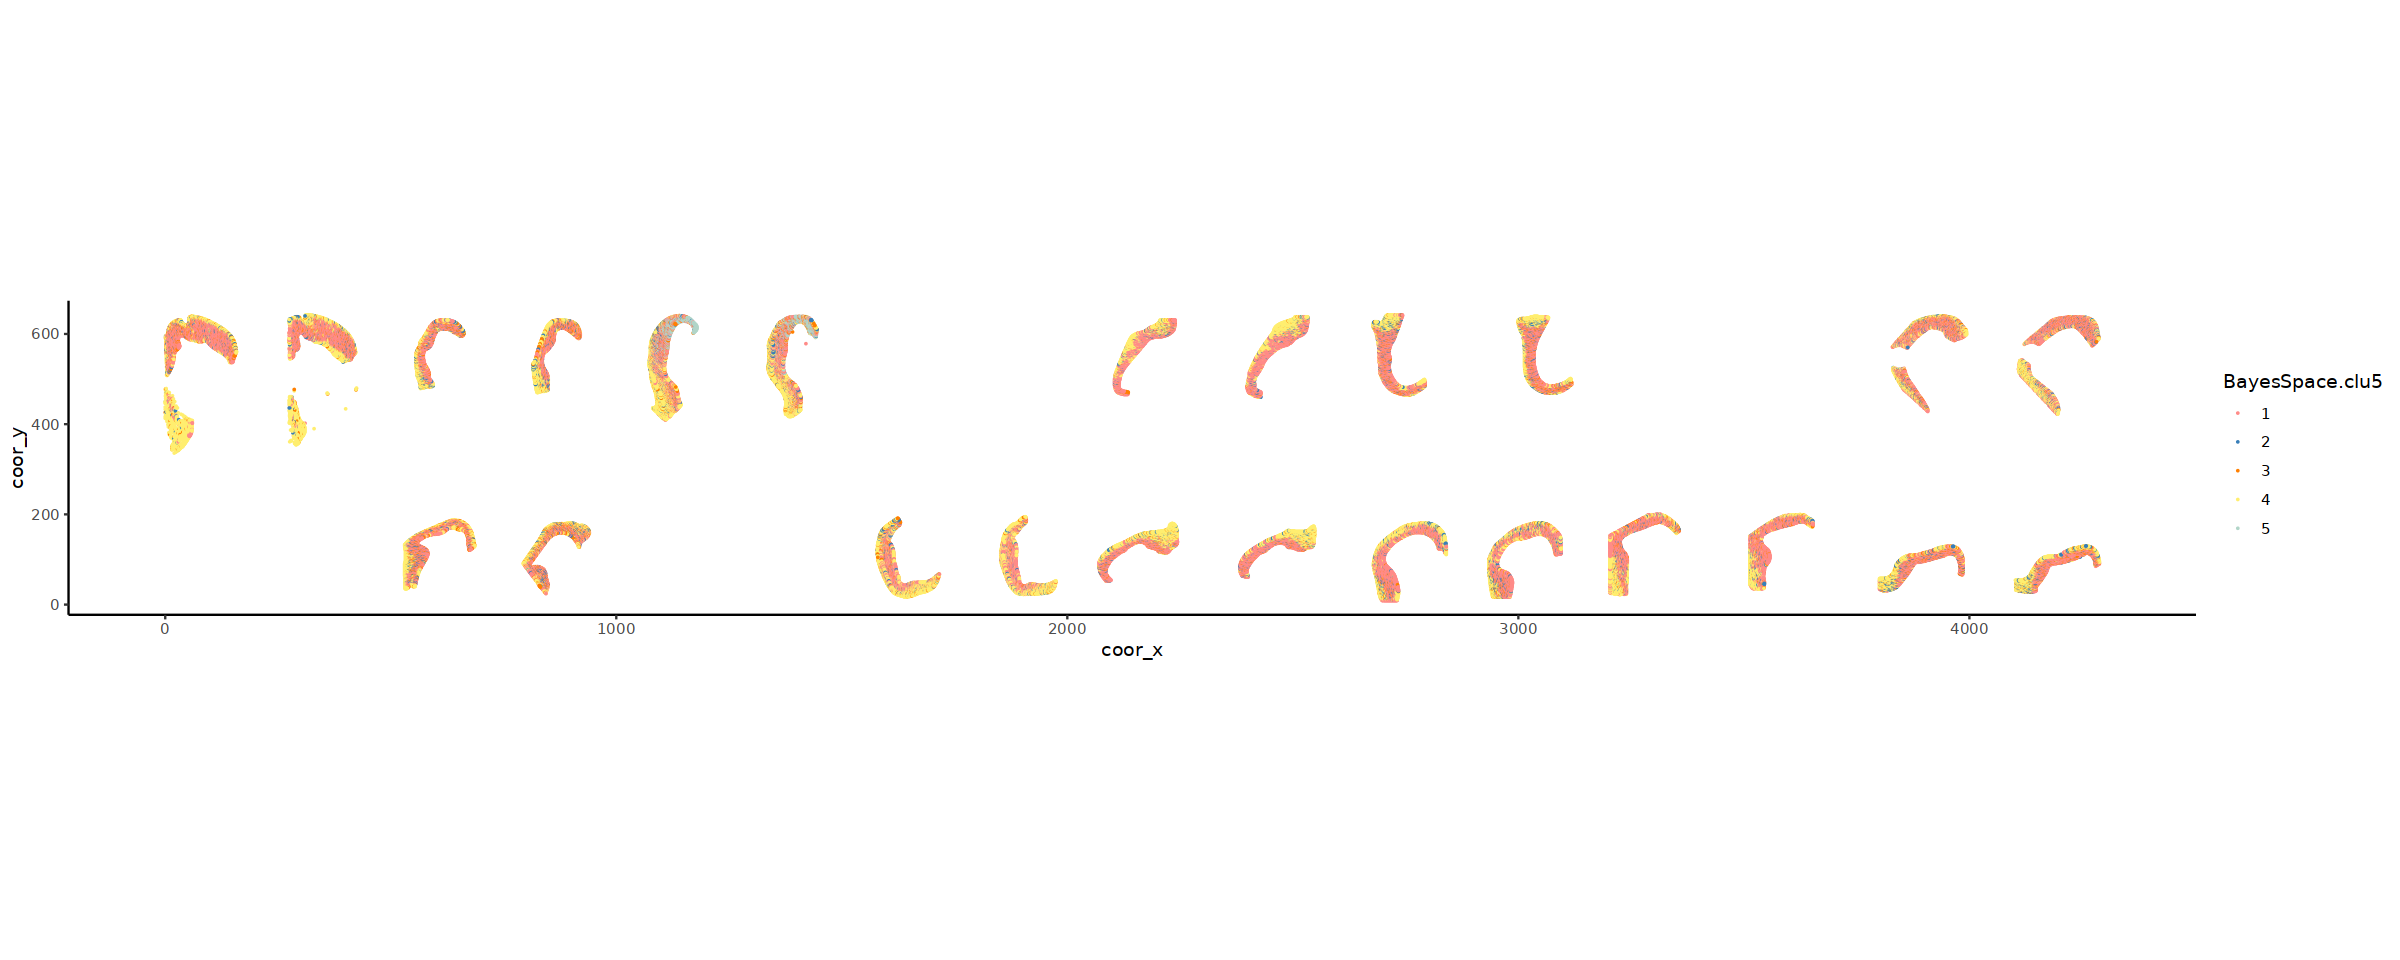

In [34]:
options(repr.plot.width = 20, repr.plot.height = 8)
#######plot bayesSpace clusters
# p <-  ggplot(alldata@meta.data,aes(as.numeric(coor_x), as.numeric(coor_y), fill= alldata@meta.data[,paste0("BayesSpace.clu",n_clu)]))+geom_tile() + theme_classic()+ coord_fixed()+ scale_fill_manual(values =cols)+
# labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+facet_wrap(. ~ alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],ncol = 5)+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))
# p
cols = c('#FF8B88','#377EB8','#FF7F00','#ffee6f','#b1d5c8')
#######plot bayesSpace clusters
n_clu = 5
p1 <-  ggplot(alldata@meta.data,aes(x = coor_x, y = coor_y, color = BayesSpace.clu5))+
geom_point(size = 0.001) +
scale_color_manual(values = cols) + 
theme_classic()+ coord_fixed()+ 
scale_fill_manual(values =cols)+
labs(fill=alldata@meta.data[,paste0("BayesSpace.clu",n_clu)],x = "coor_x",y = "coor_y")+guides(fill=guide_legend(title=paste0("BayesSpace.clu",n_clu)))
p1
# ggsave('24chips_bayes.pdf',width = 20,height = 8)

### bayes_5clusters dotplot

In [2]:
setwd('/data/work/08.脑区划分/03_返修V1_250709/03_Result/02_bin')
getwd()

[1] "/data/work/08.脑区划分/03_返修V1_250709/03_Result/02_bin"

In [39]:
options(future.globals.maxSize = 50 *1000* 1024^2)
#options(future.globals.maxSize = 5000 * 1024^2)
plan()
plan("multisession", workers = 12)
plan()
set.seed(123)

Idents(alldata) = 'BayesSpace.clu5'
scRNA1.markers <- FindAllMarkers(object = alldata,only.pos = T,min.pct = 0.1 ,logfc.threshold =0.1 )
scRNA1.markers[1:2,]
write.table(scRNA1.markers,'BayesSpace.clu5.allgenes.txt',row.names = F,quote=F,sep="\t")
table(scRNA1.markers$cluster)
scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]
write.table(sig.markers,'BayesSpace.clu5.allmarkers.txt',row.names = F,quote=F,sep="\t")
top10 <- sig.markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
write.table(top10,'BayesSpace.clu5.top10markers.txt',row.names = F,quote=F,sep="\t")

multisession:
- args: function (..., workers = 12, envir = parent.frame())
- tweaked: TRUE
- call: plan("multisession", workers = 12)

multisession:
- args: function (..., workers = 12, envir = parent.frame())
- tweaked: TRUE
- call: plan("multisession", workers = 12)

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
PLPPR4,0,0.6341711,0.736,0.551,0,1,PLPPR4
ENC1,0,0.5740760,0.937,0.853,0,1,ENC1



   1    2    3    4    5 
1062  308  229  967 2818 

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'which': object 'pct.filter' not found


In [41]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]
write.table(sig.markers,'BayesSpace.clu5.allmarkers.txt',row.names = F,quote=F,sep="\t")
top10 <- sig.markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
write.table(top10,'BayesSpace.clu5.top10markers.txt',row.names = F,quote=F,sep="\t")

In [3]:
scRNA1.markers = read.table('BayesSpace.clu5.allgenes.txt',check.names = F,header=T,sep="\t")

In [6]:
scRNA1.markers[which(scRNA1.markers$gene %in% c('FN1','ETV1','PCSK1','CAMK2G') ),]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1135,3.822431e-140,0.2066892,0.418,0.305,2.094692e-135,2,CAMK2G
1826,4.834689e-131,0.3571220,0.342,0.303,2.649410e-126,4,CAMK2G
1952,1.393214e-61,0.2365369,0.182,0.154,7.634815e-57,4,FN1
2064,1.463176e-35,0.2405285,0.193,0.175,8.018206e-31,4,ETV1


In [10]:
logFCfilter = 0.2
adjPvalFilter = 0.05
pct.filter = 0.1
scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]

# sig.markers[which(sig.markers$gene %in% c('FN1','ETV1','PCSK1','CAMK2G') ),]
sig.markers[which(sig.markers$gene %in% c('FN1','RORB1','NTNG1','SEMA3E','COL5A2') ),]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,up.down,max.pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<dbl>
4,0.000000e+00,0.5251171,0.429,0.263,0.000000e+00,1,COL5A2,up,0.429
1952,1.393214e-61,0.2365369,0.182,0.154,7.634815e-57,4,FN1,up,0.182


In [52]:
logFCfilter = 0.2
adjPvalFilter = 0.05
pct.filter = 0.1
scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]
############################################################
top10 = scRNA1.markers
top10 = top10[!duplicated(top10$gene),]
top10 = top10 %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
top10[1,]
# top10 = top10[-which(top10$gene %in% unique(top10[duplicated(top10$gene),'gene']) ),]
# top10[1,]
#top10 = top10[!duplicated(top10$gene),]
# DotPlot的features为list时，list组间会有间隔，便于比较不同celltype的marker基因差异，可视化效果更好；
# 使用split函数根据cluster列将数据框分割为列表
#每个list的内容是gene
top10deg.list <- split(top10$gene, top10$cluster)

p <- DotPlot(alldata, features = top10deg.list, assay = "RNA") + theme(axis.text.x = element_text(angle = 90, vjust = 1 , hjust=1)) +
  scale_color_gradientn(values = seq(0,1,0.2),colours = c('#330066','#336699','#66CC66','#FFCC33'))


p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,max.pct
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
0,0.6341711,0.736,0.551,0,1,PLPPR4,0.736


Warning message:
“The `facets` argument of `facet_grid()` is deprecated as of ggplot2 2.2.0.
ℹ Please use the `rows` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


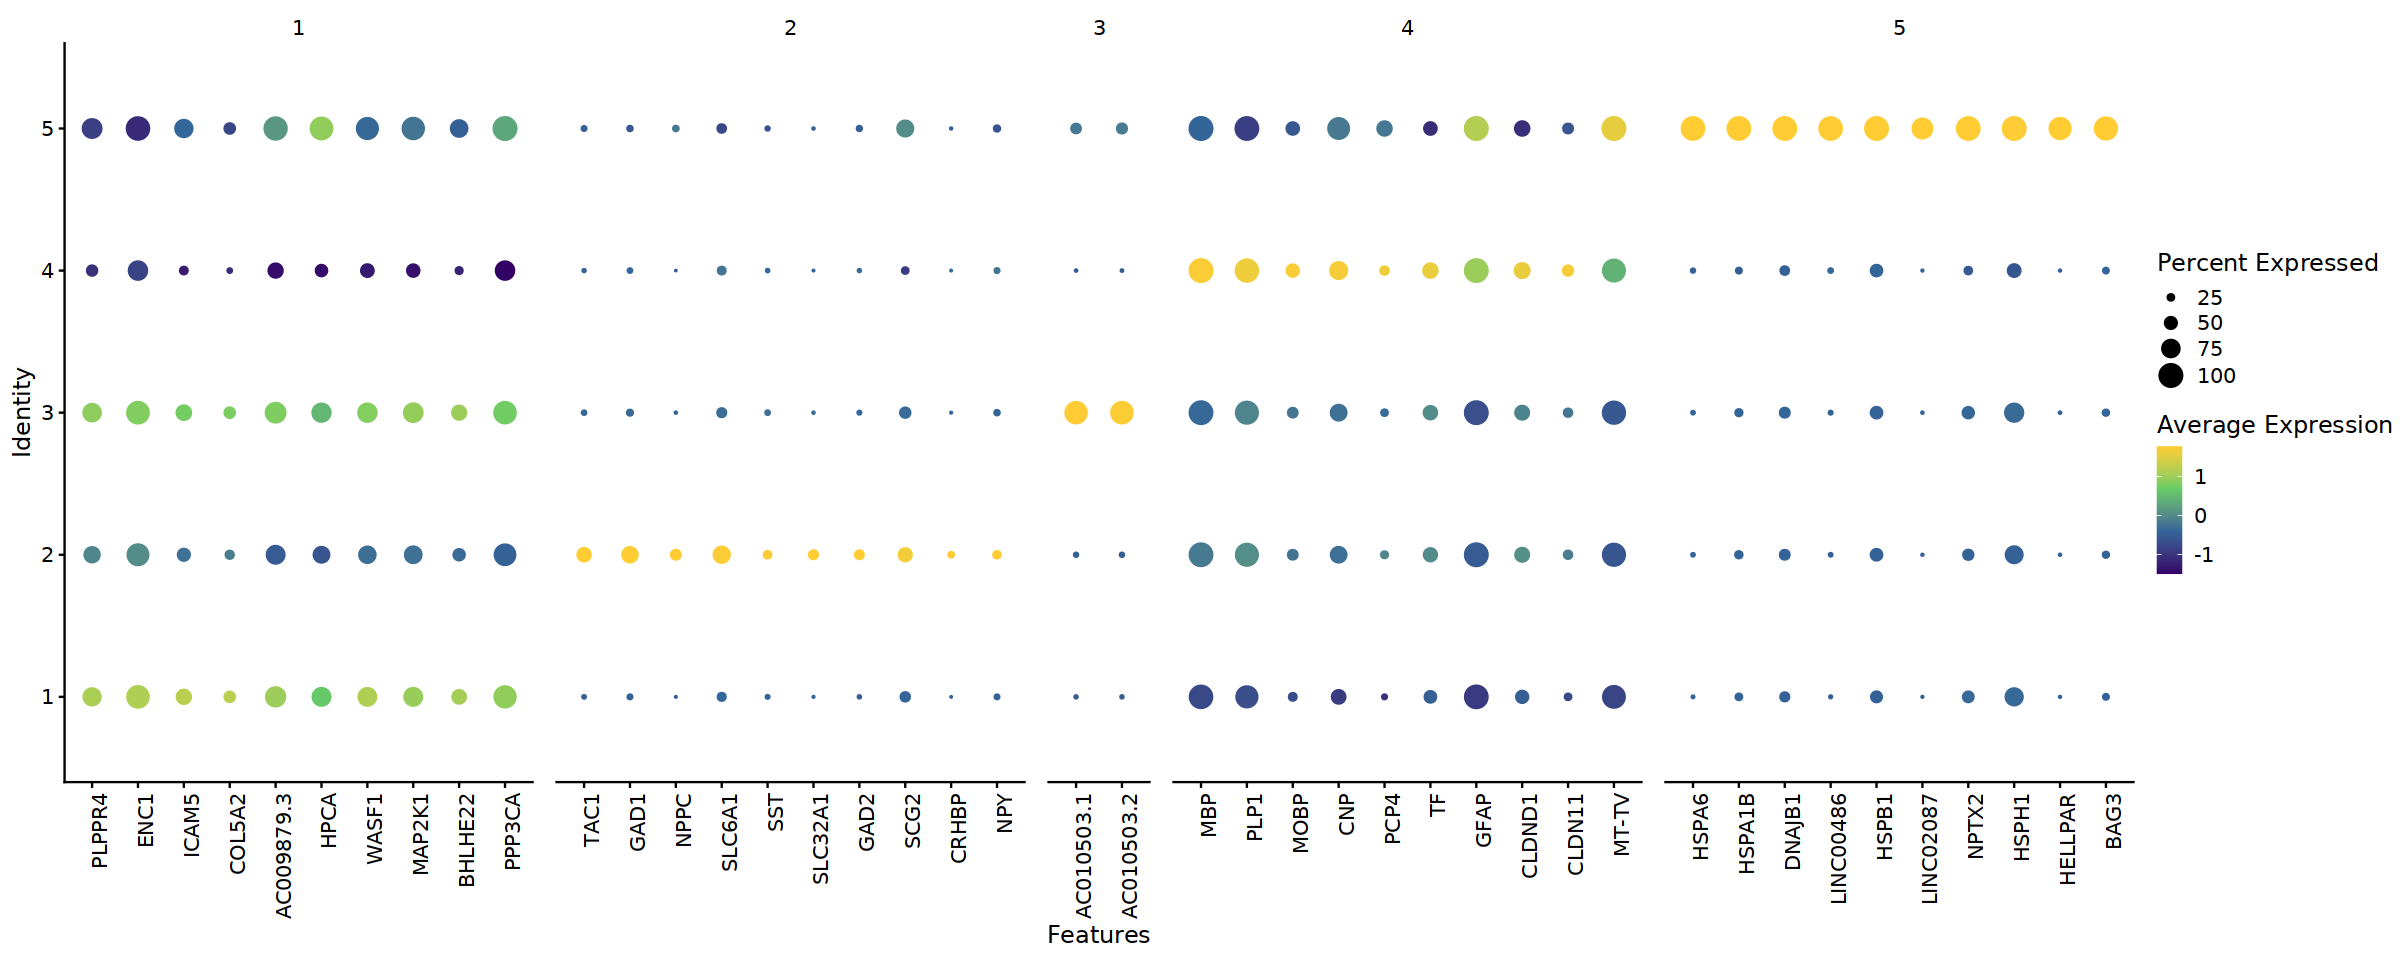

In [53]:
p

### bayes_5clusters-heatmp

In [37]:
setwd('/data/work/08.脑区划分/03_返修V1_250709/03_Result/02_bin')
getwd()

[1] "/data/work/08.脑区划分/03_返修V1_250709/03_Result/02_bin"

In [39]:
options(future.globals.maxSize = 50 *1000* 1024^2)
#options(future.globals.maxSize = 5000 * 1024^2)
plan()
plan("multisession", workers = 12)
plan()
set.seed(123)

Idents(alldata) = 'BayesSpace.clu5'
scRNA1.markers <- FindAllMarkers(object = alldata,only.pos = T,min.pct = 0.1 ,logfc.threshold =0.1 )
scRNA1.markers[1:2,]
write.table(scRNA1.markers,'BayesSpace.clu5.allgenes.txt',row.names = F,quote=F,sep="\t")
table(scRNA1.markers$cluster)
scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]
write.table(sig.markers,'BayesSpace.clu5.allmarkers.txt',row.names = F,quote=F,sep="\t")
top10 <- sig.markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
write.table(top10,'BayesSpace.clu5.top10markers.txt',row.names = F,quote=F,sep="\t")

multisession:
- args: function (..., workers = 12, envir = parent.frame())
- tweaked: TRUE
- call: plan("multisession", workers = 12)

multisession:
- args: function (..., workers = 12, envir = parent.frame())
- tweaked: TRUE
- call: plan("multisession", workers = 12)

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
PLPPR4,0,0.6341711,0.736,0.551,0,1,PLPPR4
ENC1,0,0.5740760,0.937,0.853,0,1,ENC1



   1    2    3    4    5 
1062  308  229  967 2818 

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'which': object 'pct.filter' not found


In [41]:
logFCfilter = 0.25
adjPvalFilter = 0.05
pct.filter = 0.1

scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]
write.table(sig.markers,'BayesSpace.clu5.allmarkers.txt',row.names = F,quote=F,sep="\t")
top10 <- sig.markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)
write.table(top10,'BayesSpace.clu5.top10markers.txt',row.names = F,quote=F,sep="\t")

In [43]:
scRNA1.markers[which(scRNA1.markers$gene %in% 'FN1'),]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,max.pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
FN1,1.393214e-61,0.2365369,0.182,0.154,7.634815e-57,4,FN1,0.182


In [ ]:
############################################################

In [16]:
best_color = c('#FE8A23',"#a4cee1",'#EF9A9A', "#8cd2c7",'#cb5c83','#9ECB3D','#3FB6C4','#54E8E4','#D4E157','#8D6E63','#9B7BFA','#78E08F','#DEEDCF','#94AF97','#D3A59C','#B2847B')

In [14]:
scRNA1.markers = read.table('BayesSpace.clu5.allgenes.txt',check.names = F,header=T,sep="\t")

logFCfilter = 0.2
adjPvalFilter = 0.05
pct.filter = 0.1
scRNA1.markers$max.pct = apply(scRNA1.markers[,c("pct.1","pct.2")],1,max)
sig.markers = scRNA1.markers[which(scRNA1.markers$max.pct> pct.filter & scRNA1.markers$p_val_adj<adjPvalFilter & abs(scRNA1.markers$avg_log2FC)>logFCfilter),]

In [15]:
table(sig.markers$cluster)


   1    2    3    4    5 
 320  100   14  551 1155 

In [19]:
sig.markers[1,]
summary(sig.markers$avg_log2FC)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,max.pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,0,0.6341711,0.736,0.551,0,1,PLPPR4,0.736


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2000  0.2376  0.2936  0.3771  0.3939  4.0714 

,1,2,3
,<dbl>,<dbl>,<dbl>
AARS,NA,NA,NA
ABAT,NA,0.2938419,NA
ABCA17P,NA,NA,NA


[1] "NonNeuron"

[1] 1

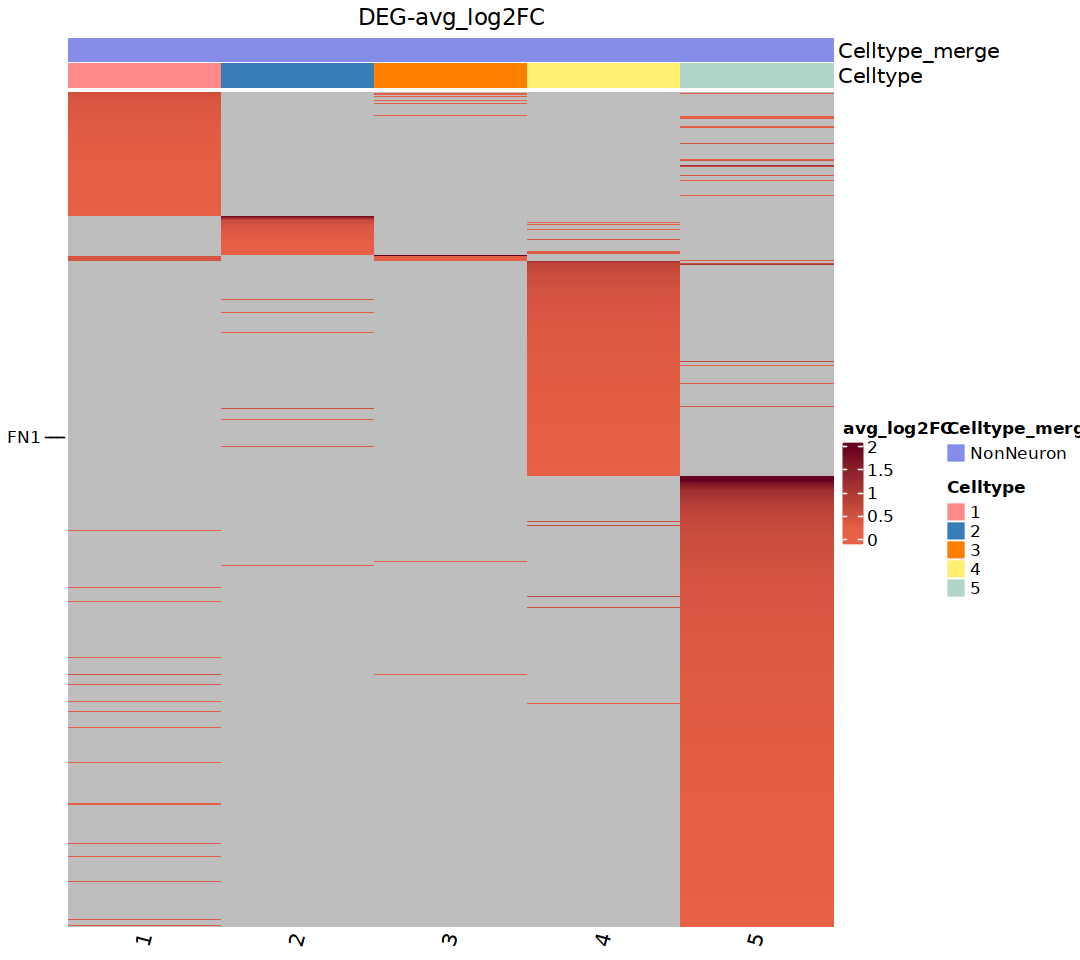

In [36]:
marker.list = sig.markers
celltype.order = c(1,2,3,4,5)

marker.list$cluster = factor(marker.list$cluster,levels =  celltype.order )
marker.list = marker.list[order(marker.list$cluster,-marker.list$avg_log2FC),]
gene.order = marker.list$gene

normalization <- function(x) { return((x - min(x)) / (max(x) - min(x))) } #定义函数
df <- marker.list[,c("gene","cluster","avg_log2FC")]

df$avg_log2FC[which(df$avg_log2FC >2)] = 2
library(data.table)
df1 <- reshape2::dcast(df,gene~cluster,value.var = "avg_log2FC")#dcast是长数据，变宽数据，~号左边是保持不变的列名，~右边是需要扩展的列名，melt是融合的意思，将宽的数据，变为长的数据
# df1[is.na(df1)] <- 0
rownames(df1) <- df1$gene
mat <- df1[,-1]
mat <-mat
mat[1:3,1:3]
#mat <- MinMax(mat,-2,2)#这里是把数据变为了值在1.2处,这是可以改的吗？不可以用log吗？seurat里的函数
mat = mat[gene.order,]
mat <- mat
#mat<-mat[order(mat$ASC_AD_F_vs_Control_F),]
mat <- as.matrix(mat)
#head(mat)
colnames(mat) = factor(colnames(mat),levels = celltype.order )

######
annotation_col = data.frame(
  Celltype_merge = gsub("_.*$", "", colnames(mat) ),
  Celltype =  colnames(mat) 
)
annotation_col$Celltype = factor(annotation_col$Celltype,levels= celltype.order )

annotation_col$Celltype_merge[which(grepl("EX|IN",annotation_col$Celltype_merge) == "FALSE" )]="NonNeuron"
row.names(annotation_col) = colnames(mat)
#head(annotation_col)
unique(annotation_col$Celltype_merge)


cols = c('#FF8B88','#377EB8','#FF7F00','#ffee6f','#b1d5c8')
cols.celltype = cols[1:length(unique(colnames(mat)))]
names(cols.celltype) = unique(colnames(mat))


top_anno = HeatmapAnnotation(
  df=annotation_col,
  col = list(
    # Celltype_merge = c(EX = "#67D5B5", IN = "#EE7785",NonNeuron = "#C89EC4"), #"#67D5B5","#EE7785","#C89EC4"
    Celltype = cols.celltype 
  )
)
#col.type <- cols.celltype[annotation_col$Celltype]


########## left.anno
top10_gene = 'FN1'
length(top10_gene)
left.anno= rowAnnotation(link = anno_mark(at = which(rownames(mat) %in% top10_gene), side ="left",
                                      labels = top10_gene, labels_gp = gpar(fontsize = 10)))
##### left.anno
options(repr.plot.width=9, repr.plot.height=8)
mat = t(mat)
# mat = scale(mat, center = T, scale = TRUE)
mat = t(mat)
p<-Heatmap(mat[,],name="avg_log2FC",
           cluster_rows = F,
           cluster_columns = F,
           #show_column_names = F,
		   show_row_names = F,
           # col = c("#A020F0","#292421","#FFFF00"),
		   col = c("#E86046","#67001F"),
		   # col = colorRampPalette(colors = c("#CE00EA","black","#FCFC39"))(20),
           #column_split = cluster_info,
		   top_annotation = top_anno,
           #right_annotation = row_anno,
           left_annotation = left.anno,
		   column_names_rot = 75, #字体斜度
		   row_names_max_width = unit(100, "cm"),
		   row_names_gp = gpar(fontsize = 12),
		   row_dend_width = unit(40, "mm"),#树的高度
		   column_dend_height = unit(40, "mm"),
		   column_names_gp = gpar(fontsize = 12),
		   column_title = "DEG-avg_log2FC" )
           
p

In [ ]:
pdf('bin_Bayes.clu5_DEG.heatmp.pdf',width = 5,height = 6)
p
dev.off()

getwd()